In [1]:
import warnings
warnings.filterwarnings("ignore")
import pickle
import mne
import neurokit2 as nk2
import time
import math
import glob, sys, os 
import numpy as np
import scipy as sp
from scipy.stats import shapiro
import seaborn as sns
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors
import joblib
import fooof as fooof
from fooof import FOOOF
import ordpy 
import logging
from scipy.stats import pearsonr, ttest_ind
import itertools
from statannotations.Annotator import Annotator

from scipy.stats import mannwhitneyu

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from scipy.stats import shapiro
from scipy.stats import levene
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import roc_curve, auc

logging.getLogger('mne').setLevel(logging.WARNING)
pd.set_option('display.max_rows', 500)

# Get Info 

In [2]:
# Load demographics + bx data 
in_dir = '/Users/derek/Documents/PICU/Manuscript_analysis/'
output_dir = f'{in_dir}/Manuscript Redo/Figures/'

metric_o_i = ['SampEn','PEn','CWPEn','LZC_PSN', 'LZC', 'LE','HiguchiFD','dfa','dfaDelta','dfaTheta','dfaAlpha',
              'FOOOF_Offset','FOOOF_Slope', '|delta|Power', 'delta_RelPower','|theta|Power','theta_RelPower','|alpha|Power',
              'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower']

metric_interested = ['SampEn','PEn','CWPEn','LZC','LE','HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power','|alpha|Power', '|beta|Power', '|low-gamma|Power',]

# Define metric_names dictionary for proper naming
metric_names = {
    "SampEn": "Sample Entropy",
    "PEn": "Permutation Entropy",
    "CWPEn": "Conditional Weighted Permutation Entropy",
    "LZC_PSN": "Lempel-Ziv Complexity-Phase Shuffled",
    "LZC": "Lempel-Ziv Complexity",
    "LE": "Lyapunov Exponent",
    "HiguchiFD": "Higuchi Fractal Dimension",
    "dfa": "Detrended Fluctuation Analysis",
    "dfaDelta": "Detrended Fluctuation Analysis Delta",
    "dfaTheta": "Detrended Fluctuation Analysis Theta",
    "dfaAlpha": "Detrended Fluctuation Analysis Alpha",
    "FOOOF_Offset": "Spectral Slope Offset",
    "FOOOF_Slope": "Spectral Slope",
    "|delta|Power": "Absolute Delta Power",
    "delta_RelPower": "Delta Relative Power",
    "|theta|Power": "Absolute Theta Power",
    "theta_RelPower": "Relative Theta Power",
    "|alpha|Power": "Absolute Alpha Power",
    "alpha_RelPower": "Relative Alpha Power",
    "|beta|Power": "Absolute Beta Power",
    "beta_RelPower": "Relative Beta Power",
    "|low-gamma|Power": "Absolute Gamma Power",
    "low-gamma_RelPower": "Relative Gamma Power",
}

# Define metrics of interest
metric_interested = ['SampEn', 'PEn', 'CWPEn', 'LZC', 'LE', 'HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power', '|alpha|Power', '|beta|Power', '|low-gamma|Power']

def extract_participant_id(file):
    return file[:9]
    
#vis_dem = pd.read_csv("/Users/derek/Documents/PICU/Manuscript_analysis/Visual_df.csv")
demo_csv = f'{in_dir}/PICU_DEMO_Clean.csv'
demos = pd.read_csv(demo_csv)
demos = demos.drop(['Unnamed: 16','Unnamed: 17'], axis=1)
demos = demos.drop([41])
filtered_data_age = demos[demos['age_years'] <= 5][['participant_id']]
filtered_data_gose = demos[demos['GOSE_3mo'].isna() | (demos['GOSE_3mo'] == '') | ~np.isfinite(demos['GOSE_3mo'])][['participant_id']]
filtered_data_age_gose = demos[
    (demos['age_years'] >= 5) & 
    (demos['GOSE_3mo'].notna()) & 
    (demos['GOSE_3mo'] != '')]

print(f"# Old Metrics {len(metric_o_i)}, # New Metrics {len(metric_interested)}")
ordered_file = f"{in_dir}/all_temporal_order.csv"
ordered_files_csv = pd.read_csv(ordered_file)
output_filename = f"{in_dir}/all_data_name.pkl"

print(f"Data retrieved from {output_filename}")
with open(output_filename, 'rb') as input_file:
    all_data_name_loaded = pickle.load(input_file)

orig_keys_all_files = all_data_name_loaded.keys()

base_files = []
for i in orig_keys_all_files:
    if "ase" in i:
        base_files.append(i)
for i in orig_keys_all_files:
    filename = i
    if "HM" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "ent" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "orphine" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
        
sed_files = []
for i in orig_keys_all_files:
    filename = i
    if filename not in base_files:
        if "Ket" not in filename:
            sed_files.append(filename)
prop_files = []
for i in sed_files:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files.append(filename)
mid_files = []
for i in sed_files:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files.append(filename)
dex_mix_files = []
for i in sed_files:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files.append(filename)

# naming is off, is rop, for the processed files to have drop added in changes my naming and how i searched through 
# total ordered files listed from raw is 393
print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files)) # 56 propofol 
print("Mid files: ",len(mid_files)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files)) # 67 various 

print(all_data_name_loaded['sub-001AC_Baseline_pre_sed_drop_chs_'].keys())

all_data_name = all_data_name_loaded
all_data_median = {}
for file, data in all_data_name.items():
    metrics = []
    for metric in metric_o_i:
        med_met = np.median(all_data_name[file][metric])
        metrics.append(med_met)
    all_data_median[file] = metrics

sedation_data = {}
for i,k in all_data_median.items():
    if i in sed_files:
        sedation_data[i] =k

#sedation_data
prop_data = {}
for i,k in all_data_median.items():
    if i in prop_files:
        prop_data[i] =k
mid_data = {}
for i,k in all_data_median.items():
    if i in mid_files:
        mid_data[i] =k
dex_mix_data = {}
for i,k in all_data_median.items():
    if i in dex_mix_files:
        dex_mix_data[i] =k

# Old Metrics 23, # New Metrics 14
Data retrieved from /Users/derek/Documents/PICU/Manuscript_analysis//all_data_name.pkl
All files:  366
Base files:  82
Sed files:  266
Prop files:  56
Mid files:  143
Dex_mix files:  67
dict_keys(['SampEn', 'PEn', 'CWPEn', 'LZC_PSN', 'LZC', 'LE', 'HiguchiFD', 'dfa', 'dfaDelta', 'dfaTheta', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', 'delta_RelPower', '|theta|Power', 'theta_RelPower', '|alpha|Power', 'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower'])


# HANDLE PROPER KEYS AND DUPLICATES 

In [3]:
goodkeys = []
for key, data in all_data_name.items():
    if key in sedation_data.keys():
        print(key)
        goodkeys.append(key)
len(goodkeys)

sub-002AC_HM_5-12mcgkghr_Midaz_30mcgkghr_
sub-002AC_HM_5-12mcgkghr_Prop_10-90mcgkgmin_
sub-002AC_HM_5-12mcgkghr_Prop_20mcgkgmin_
sub-002AC_HM_5-12mcgkghr_Prop_40-60mcgkgmin_A_
sub-002AC_HM_5-12mcgkghr_Prop_40-60mcgkgmin_B_
sub-002AC_HM_5-12mcgkghr_Prop_70mcgkgmin_
sub-002AC_HM_5-12mcgkghr_Prop_70mcgkgmin_steady_
sub-003AC_HM_4-10mcgkghr_Prop_60-100mcgkghr_drop_chs_
sub-003AC_HM_4-8mcgkghr_Prop_60-100mcgkghr_
sub-003MC_Midaz_1ugkgmin_A_
sub-003MC_Midaz_1ugkgmin_B_
sub-003MC_Midaz_2ugkgmin_A_
sub-003MC_Midaz_2ugkgmin_B_
sub-003MC_Midaz_3ugkgmin_
sub-003MC_Midaz_4ugkgmin_
sub-003MC_Midaz_5ugkgmin_
sub-003MC_Propofol_1mgkghr_Dexmedetomidine_1,2ugkghr_epochs_dr
sub-003MC_Propofol_INF_2mgkghr_Dexmedetomidone_1ugkghr_epochs_dr
sub-003MC_Propofol_INF_3mgkghr_Dexmedetomidine_1,2ugkghr_epochs_dr
sub-004AC_HM_10mcgkghr_Prop_10-25mcgkghr_
sub-004AC_HM_10mcgkghr_Prop_15-40mcgkghr_
sub-004MC_Midazolam_3ugkgmin_30_min_
sub-004MC_Midazolam_3ugkgmin_
sub-004MC_Propofol_INF_2mgkghr_20_min_
sub-004MC_Pro

266

# Delete Duplicates and Patients without Data 

In [6]:
sed_ids = []
for i in sed_files:
    idx= i[:9]
    sed_ids.append(idx)

unique_ids_sed = np.unique(np.array(sed_ids))

print(f"# patients with Sed: {len(unique_ids_sed)}")

# Who does not have GOSE 
excluded_subs = ['sub-023MC', 'sub-002AC', 'sub-004AC', 'sub-005AC', 'sub-007AC', 'sub-008AC','sub-010AC',
                 'sub-001MC','sub-002MC','sub-003MC','sub-004MC','sub-005MC', 'sub-007MC','sub-009MC','sub-010MC','sub-012MC','sub-024MC','sub-006AC','sub-012AC']

bx_ids = list(filtered_data_age_gose['participant_id'])

new_seds = []
for i in sed_files:
    if all(sub not in i for sub in excluded_subs) and i not in new_seds:
        new_seds.append(i)

unique_ids = set()
for item in new_seds:
    unique_id = item.split('_')[0]
    unique_ids.add(unique_id)
unique_ids = list(unique_ids)

print(len(unique_ids))

prop_files_UP = []
for i in new_seds:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files_UP.append(filename)
mid_files_UP = []
for i in new_seds:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files_UP.append(filename)
dex_mix_files_UP = []
for i in new_seds:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files_UP.append(filename)

print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files), " Now:", len(new_seds)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files), " Now:", len(prop_files_UP)) # 56 propofol 
print("Mid files: ",len(mid_files), " Now:", len(mid_files_UP)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files), " Now:", len(dex_mix_files_UP)) # 67 various 

# patients with Sed: 49
32
All files:  366
Base files:  82
Sed files:  266  Now: 175
Prop files:  56  Now: 24
Mid files:  143  Now: 104
Dex_mix files:  67  Now: 47


# Retrieve Data 

In [9]:
sedation_data_CUT = {}
for i,k in all_data_median.items():
    if i in new_seds:
        sedation_data_CUT[i] =k

#sedation_data
prop_data_CUT = {}
for i,k in all_data_median.items():
    if i in prop_files_UP:
        prop_data_CUT[i] =k
mid_data_CUT = {}
for i,k in all_data_median.items():
    if i in mid_files_UP:
        mid_data_CUT[i] =k
dex_mix_data_CUT = {}
for i,k in all_data_median.items():
    if i in dex_mix_files_UP:
        dex_mix_data_CUT[i] =k

# Feature Group Differences 

In [10]:
for metric_name in metric_interested:
    # Prepare data
    prop_met_data = [{'Condition': 'Propofol', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                     for filename, metrics in prop_data.items()]
    mid_met_data = [{'Condition': 'Midazolam', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                    for filename, metrics in mid_data.items()]
    dex_mix_met_data = [{'Condition': 'Dex_mix', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                       for filename, metrics in dex_mix_data.items()]
    met_data = prop_met_data + mid_met_data + dex_mix_met_data
    df = pd.DataFrame(met_data)
    df = df.merge(vis_dem[['participant_id', 'GOSE_3mo', 'injury_etiology_cleaned', 'age_years']], 
                  how='left', left_on='Participant ID', right_on='participant_id')
    df = df[df['GOSE_3mo'].notna() & (df['age_years'] >= 5)]
    df['edge_color'] = df['GOSE_3mo'].apply(lambda x: 1 if x >= 4 else 2)
    df['recovery'] = df['edge_color'].map({1: 'Recovered', 2: 'Non-Recovered'})    

    # Mann-Whitney U test for statistical annotation
    if len(df['recovery'].unique()) > 1:
        recovery1 = 'Recovered'
        recovery2 = 'Non-Recovered'
        values1 = df[df['recovery'] == recovery1][metric_name]
        values2 = df[df['recovery'] == recovery2][metric_name]
        u_stat, p_val = mannwhitneyu(values1, values2, alternative='two-sided')
        
        # Calculate medians
        median1 = np.median(values1)
        median2 = np.median(values2)
        
        # Print results with emphasis on statistically significant results
        if p_val < 0.05:
            print(f"\033[1m{metric_name}: U = {u_stat:.4f}, p = {p_val:.4f}, "
                  f"Median1 (Recovered) = {median1:.2f}, Median2 (Not Recovered) = {median2:.2f}\033[0m")
        else:
            print(f"{metric_name}: U = {u_stat:.4f}, p = {p_val:.4f}, "
                  f"Median1 (Recovered) = {median1:.2f}, Median2 (Not Recovered) = {median2:.2f}")


SampEn: U = 4151.0000, p = 0.0163, Median1 (Recovered) = 0.12, Median2 (Not Recovered) = 0.09
PEn: U = 4093.0000, p = 0.0266, Median1 (Recovered) = 0.87, Median2 (Not Recovered) = 0.85
CWPEn: U = 2896.0000, p = 0.1155, Median1 (Recovered) = 0.08, Median2 (Not Recovered) = 0.09
LZC: U = 5253.5000, p = 0.0000, Median1 (Recovered) = 0.23, Median2 (Not Recovered) = 0.13
LE: U = 2768.0000, p = 0.0478, Median1 (Recovered) = 0.00, Median2 (Not Recovered) = 0.00
HiguchiFD: U = 4523.0000, p = 0.0003, Median1 (Recovered) = 1.91, Median2 (Not Recovered) = 1.90
dfaAlpha: U = 4687.0000, p = 0.0000, Median1 (Recovered) = 0.66, Median2 (Not Recovered) = 0.59
FOOOF_Offset: U = 3014.0000, p = 0.2302, Median1 (Recovered) = -0.43, Median2 (Not Recovered) = -0.34
FOOOF_Slope: U = 2071.0000, p = 0.0000, Median1 (Recovered) = 2.30, Median2 (Not Recovered) = 2.81
|delta|Power: U = 2981.0000, p = 0.1921, Median1 (Recovered) = 0.36, Median2 (Not Recovered) = 0.40
|theta|Power: U = 4231.0000, p = 0.0079, Median

In [11]:
# CORRECT FOR MULTIPLE COMPARISONS
from statsmodels.stats.multitest import multipletests

# List to store test results for each metric
results = []

for metric_name in metric_interested:
    # Prepare data
    prop_met_data = [{'Condition': 'Propofol', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                     for filename, metrics in prop_data.items()]
    mid_met_data = [{'Condition': 'Midazolam', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                    for filename, metrics in mid_data.items()]
    dex_mix_met_data = [{'Condition': 'Dex_mix', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                       for filename, metrics in dex_mix_data.items()]
    met_data = prop_met_data + mid_met_data + dex_mix_met_data
    df = pd.DataFrame(met_data)
    df = df.merge(vis_dem[['participant_id', 'GOSE_3mo', 'injury_etiology_cleaned', 'age_years']], 
                  how='left', left_on='Participant ID', right_on='participant_id')
    df = df[df['GOSE_3mo'].notna() & (df['age_years'] >= 5)]
    df['edge_color'] = df['GOSE_3mo'].apply(lambda x: 1 if x >= 4 else 2)
    df['recovery'] = df['edge_color'].map({1: 'Recovered', 2: 'Non-Recovered'})   
    
    # Only perform the test if there are two groups
    if len(df['recovery'].unique()) > 1:
        recovery1 = 'Recovered'
        recovery2 = 'Non-Recovered'
        values1 = df[df['recovery'] == recovery1][metric_name]
        values2 = df[df['recovery'] == recovery2][metric_name] 
        # Perform Mann–Whitney U test
        u_stat, p_val = mannwhitneyu(values1, values2, alternative='two-sided')
        # Compute medians
        median1 = np.median(values1)
        median2 = np.median(values2)
        
        # Save the results for this metric
        results.append({
            'metric': metric_name,
            'u_stat': u_stat,
            'raw_p': p_val,
            'median1': median1,
            'median2': median2})

# Extract raw p-values and apply Bonferroni correction for multiple comparisons
raw_pvals = [res['raw_p'] for res in results]
# multipletests returns (reject, pvals_corrected, _, _)
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
# Print the test results, emphasizing those that remain significant after correction
for i, res in enumerate(results):
    metric_name = res['metric']
    u_stat = res['u_stat']
    raw_p = res['raw_p']
    corrected_p = pvals_corrected[i]
    median1 = res['median1']
    median2 = res['median2']
    # Bold printing if corrected p-value is significant (< 0.05)
    if corrected_p < 0.05:
        print(f"\033[1m{metric_name}: U = {u_stat:.4f}, raw p = {raw_p:.8f}, corrected p = {corrected_p:.8f}, "
            f"Median (Recovered) = {median1:.5f}, Median (Non-Recovered) = {median2:.5f}\033[0m")
    else:
        print(f"{metric_name}: U = {u_stat:.4f}, raw p = {raw_p:.8f}, corrected p = {corrected_p:.8f}, "
            f"Median (Recovered) = {median1:.5f}, Median (Non-Recovered) = {median2:.5f}")

SampEn: U = 4151.0000, raw p = 0.01634593, corrected p = 0.22884303, Median (Recovered) = 0.11662, Median (Non-Recovered) = 0.09153
PEn: U = 4093.0000, raw p = 0.02660587, corrected p = 0.37248214, Median (Recovered) = 0.86623, Median (Non-Recovered) = 0.84908
CWPEn: U = 2896.0000, raw p = 0.11553615, corrected p = 1.00000000, Median (Recovered) = 0.08399, Median (Non-Recovered) = 0.09079
LZC: U = 5253.5000, raw p = 0.00000000, corrected p = 0.00000005, Median (Recovered) = 0.22548, Median (Non-Recovered) = 0.13042
LE: U = 2768.0000, raw p = 0.04775754, corrected p = 0.66860551, Median (Recovered) = 0.00179, Median (Non-Recovered) = 0.00205
HiguchiFD: U = 4523.0000, raw p = 0.00034326, corrected p = 0.00480568, Median (Recovered) = 1.90871, Median (Non-Recovered) = 1.89578
dfaAlpha: U = 4687.0000, raw p = 0.00004130, corrected p = 0.00057818, Median (Recovered) = 0.66445, Median (Non-Recovered) = 0.58949
FOOOF_Offset: U = 3014.0000, raw p = 0.23023378, corrected p = 1.00000000, Median 

In [12]:
def count_recovered_non_recovered(df):
    # Standardize recovery labels to lower case
    df['recovery'] = df['recovery'].str.strip().str.lower()
    
    # Count unique participants in each recovery group
    recovery_counts = df.groupby('recovery')['Participant ID'].nunique()
    recovered_count = recovery_counts.get('recovered', 0)
    non_recovered_count = recovery_counts.get('non-recovered', 0)
    
    # Count total number of files (rows) in each recovery group
    file_counts = df.groupby('recovery').size()
    recovered_files = file_counts.get('recovered', 0)
    non_recovered_files = file_counts.get('non-recovered', 0)
    
    return recovered_count, non_recovered_count, recovered_files, non_recovered_files

# Apply the function
recovered_count, non_recovered_count, recovered_files, non_recovered_files = count_recovered_non_recovered(df)

print(f"Number of recovered participants: {recovered_count}")
print(f"Number of non-recovered participants: {non_recovered_count}")
print(f"Number of files for recovered participants: {recovered_files}")
print(f"Number of files for non-recovered participants: {non_recovered_files}")
print(len(prop_met_data))
print(len(mid_met_data))
print(len(dex_mix_met_data))

Number of recovered participants: 22
Number of non-recovered participants: 10
Number of files for recovered participants: 117
Number of files for non-recovered participants: 58
56
143
67


# Ordinal Analysis

In [70]:
# This analysis looks at the size of the groups at different thresholds and tells you\
# how likely the predictor will be influenced by the outcome ratio (odds ration),
# OR > 1: Higher predictor values are associated with higher odds of the outcome.
# OR < 1: Higher predictor values are associated with lower odds of the outcome.
# OR = 1: No association between the predictor and the outcome.

# Ordinal Shift 

In [16]:
from math import exp, log, sqrt
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

ordinal_shift_results = []

all_metric_df = {}

for metric_name in metric_interested:
    # Prepare data for the specific metric
    prop_met_data = [{'Condition': 'Propofol', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                     for filename, metrics in prop_data.items()]
    mid_met_data = [{'Condition': 'Midazolam', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                    for filename, metrics in mid_data.items()]
    dex_mix_met_data = [{'Condition': 'Dex_mix', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                       for filename, metrics in dex_mix_data.items()]
    
    # Combine all data into a single DataFrame
    met_data = prop_met_data + mid_met_data + dex_mix_met_data
    df = pd.DataFrame(met_data)
    
    # Merge with demographic information
    df = df.merge(demos[['participant_id', 'GOSE_3mo', 'Etiology', 'age_years']], how='left', left_on='Participant ID', right_on='participant_id')
    df = df[df['GOSE_3mo'].notna() & (df['age_years'] >= 5)]
    
    # Loop through each GOSE value as a dynamic recovery threshold
    gose_values = range(1, 9)
    for threshold in gose_values:
        # Assign recovery status based on the current threshold
        df['recovery'] = df['GOSE_3mo'].apply(lambda x: 1 if x > threshold else 0)

        # Calculate group sizes for recovered and non-recovered
        recovered_size = len(df[df['recovery'] == 1])
        non_recovered_size = len(df[df['recovery'] == 0])

        # Check if both groups have sufficient data
        if recovered_size > 0 and non_recovered_size > 0:
            # Perform Mann-Whitney U test
            recovered_data = df[df['recovery'] == 1][metric_name]
            non_recovered_data = df[df['recovery'] == 0][metric_name]
            u_stat, p_val = mannwhitneyu(recovered_data, non_recovered_data, alternative='two-sided')
            
            # Odds ratio calculation
            a = recovered_size  # Number of recovered
            b = non_recovered_size  # Number of non-recovered
            
            # Odds Ratio formula
            odds_ratio = (a / b) if b > 0 else np.nan
   
            # Confidence Interval calculation for OR
            if not np.isnan(odds_ratio) and odds_ratio > 0:
                log_or = log(odds_ratio)
                se_log_or = sqrt(1/a + 1/b)
                ci_lower = exp(log_or - 1.96 * se_log_or)
                ci_upper = exp(log_or + 1.96 * se_log_or)
            else:
                ci_lower, ci_upper = np.nan, np.nan
            
            # Append results for this metric and threshold
            ordinal_shift_results.append({
                'Metric': metric_name,
                'GOSE_Threshold': threshold,
                'Recovered_Size': recovered_size,
                'Non_Recovered_Size': non_recovered_size,
                'U_Statistic': u_stat,
                'P_Value': p_val,
                'Odds_Ratio': odds_ratio,
                'CI_Lower': ci_lower,
                'CI_Upper': ci_upper
            })
        else:
            # Append NA if insufficient data
            ordinal_shift_results.append({
                'Metric': metric_name,
                'GOSE_Threshold': threshold,
                'Recovered_Size': recovered_size,
                'Non_Recovered_Size': non_recovered_size,
                'U_Statistic': np.nan,
                'P_Value': np.nan,
                'Odds_Ratio': np.nan,
                'CI_Lower': np.nan,
                'CI_Upper': np.nan
            })

# Convert results to a DataFrame for plotting
ordinal_shift_df = pd.DataFrame(ordinal_shift_results) 


In [ ]:
ordinal_data['Total_Size'] = ordinal_data['Recovered_Size'] + ordinal_data['Non_Recovered_Size']
ordinal_data['Recovery_Percentage'] = (ordinal_data['Recovered_Size'] / ordinal_data['Total_Size']) * 100
ordinal_data['Non_Recovery_Percentage'] = (ordinal_data['Non_Recovered_Size'] / ordinal_data['Total_Size']) * 100

ordinal_data = ordinal_data.reset_index(drop=True)
ordinal_data

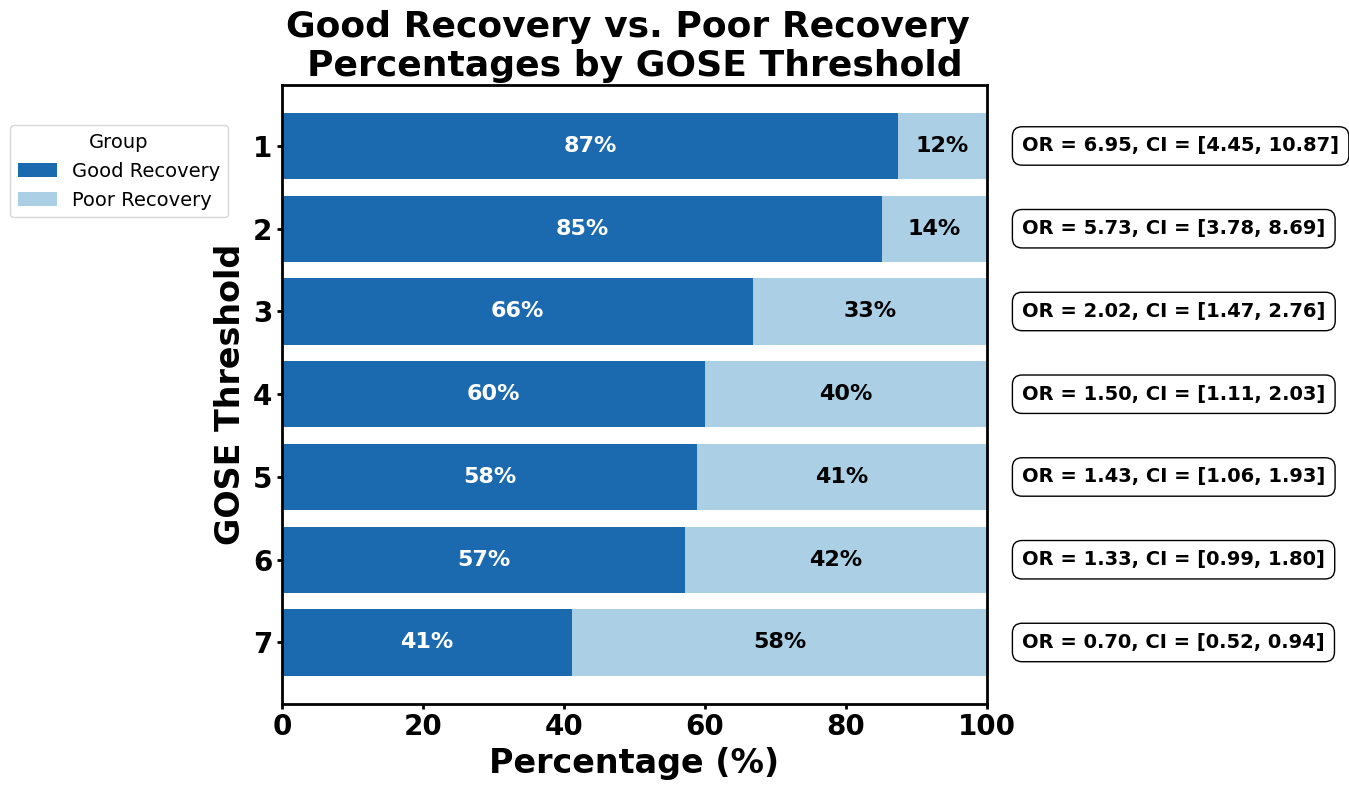

In [22]:
# Define colors
colors = sns.color_palette("Blues", n_colors=len(ordinal_data['GOSE_Threshold']))

# Filter out the eighth threshold
filtered_data = ordinal_data[ordinal_data['GOSE_Threshold'] < 8]

# Plot horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Plot Recovery and Non-Recovery bars
ax.barh(filtered_data['GOSE_Threshold'], filtered_data['Recovery_Percentage'], color=colors[-2], label='Good Recovery')
ax.barh(filtered_data['GOSE_Threshold'], filtered_data['Non_Recovery_Percentage'], 
        left=filtered_data['Recovery_Percentage'], color=colors[2], label='Poor Recovery')

# Annotate group sizes
for i, row in filtered_data.iterrows():
    ax.text(row['Recovery_Percentage'] / 2, row['GOSE_Threshold'], f"{int(row['Recovery_Percentage'])}%", color='white', ha='center', va='center', fontsize=16, fontweight='bold')
    ax.text(row['Recovery_Percentage'] + row['Non_Recovery_Percentage'] / 2, row['GOSE_Threshold'], f"{int(row['Non_Recovery_Percentage'])}%", color='black', ha='center', va='center', fontsize=16, fontweight='bold')

# Add OR, CI, and p-value as text boxes
for i, row in filtered_data.iterrows():
    text_box = (
        f"OR = {row['Odds_Ratio']:.2f}, "
        f"CI = [{row['CI_Lower']:.2f}, {row['CI_Upper']:.2f}]"
        #f"P = {row['P_Value']:.3f}"
    )
    ax.text(105, row['GOSE_Threshold'], text_box, color='black', ha='left', va='center', fontsize=14, fontweight='bold', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Formatting
ax.set_xlabel('Percentage (%)', fontsize=24, fontweight='bold')
ax.set_ylabel('GOSE Threshold', fontsize=24, fontweight='bold')
ax.set_title('Good Recovery vs. Poor Recovery \nPercentages by GOSE Threshold', fontsize=26, fontweight='bold')

# Customize legend and move it outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(-0.4, 0.95), title='Group', fontsize=14, title_fontsize=14, frameon=True)

# Set axis limits, ticks, and styles
ax.set_xlim(0, 100)  # Extend x-axis to accommodate text boxes
ax.set_yticks(filtered_data['GOSE_Threshold'])
ax.set_yticklabels(filtered_data['GOSE_Threshold'], fontsize=24, fontweight='bold')
ax.set_xticklabels(np.arange(0, 101, 20),fontsize=24, fontweight='bold')
ax.tick_params(axis='x', labelsize=20, width=2)
ax.tick_params(axis='y', labelsize=20, width=2)
ax.invert_yaxis()

# Make the outline of the plot bold
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# Adjust layout and display
plt.tight_layout()
plt.savefig(f"/Users/derek/Documents/PICU/Manuscript_analysis/Manuscript Redo/Figures/tif_figures/sliding.tif",dpi=600, format='tif')  # Include both legends in the bounding box
plt.show()
